# **1. Scaled Dot-Product Attention from Scratch**

Implement the attention mechanism used in Transformer models from scratch using only
torch and matplotlib. Do not use nn.MultiheadAttention or any built-in attention
layer.

## **a) Implementation of Attention Function.**
    i. Implement a function scaled dot product attention(Q, K, V) that computes:
        Attention(Q, K, V ) = softmax (QK⊤√dk)V

    ii. Ensure that the function returns:
        • The output context vectors
        • The attention weight matrix

    iii. Test the function using random tensors of shape (seq len = 6, dk = 8).

    iv. Print the shapes of the attention output and the attention weight matrix.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import math
import matplotlib.pyplot as plt

In [2]:
def scaled_dot_product_attention(Q, K, V):
    dk = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(dk, dtype=torch.float32))
    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

In [3]:
Q = torch.randn(6, 8)
K = torch.randn(6, 8)
V = torch.randn(6, 8)

In [4]:
output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output Shape:", output.shape)
print("Attention Weights Shape:", weights.shape)

Attention Output Shape: torch.Size([6, 8])
Attention Weights Shape: torch.Size([6, 6])


## **b) Visualization of Attention Weights**
    i. Consider the toy sentence:
        ”The cat sat on the mat”

    ii. Define the tokens as:
        [”The”, ”cat”, ”sat”, ”on”, ”the”, ”mat”]

    iii. Represent each token as a random vector of dimension dk = 8.

    iv. Use torch.manual seed(42) for reproducibility.

    v. Use the same embedding matrix as Q, K, and V (self-attention).

    vi. Compute the attention weights using the implemented function.

    vii. Plot the 6 × 6 attention weight matrix using matplotlib.pyplot.imshow.

    viii. Label both axes with token names and include a colorbar.

    ix. Note that the value at row i, column j represents how much token i attends to token j.

In [5]:
torch.manual_seed(42)

In [6]:
tokens = ["The", "cat", "sat", "on", "the", "mat"]
embeddings = torch.randn(6, 8)

In [7]:
_, attn_weights = scaled_dot_product_attention(embeddings, embeddings, embeddings)

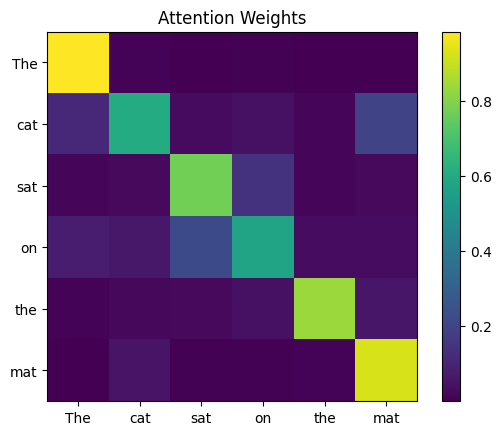

In [8]:
plt.imshow(attn_weights.detach().numpy())
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title("Attention Weights")
plt.show()

Here, the colour represents how much token i attends to token j for the value at row i and column j. We can see that when i=n-j, that is, when its the same token, the value is really high since they are the same token, and thus will have highest attention weights.

# **2. Transformer-based Emotion Classification using the given dataset.**
    Using the provided train.csv and test.csv files, implement a Transformer-based model
    to classify emotions from text. Do not use any pretrained models or internet resources.
    Use only standard libraries such as torch, pandas, and matplotlib.

## **a) Data Loading and Preprocessing**

### **i. Load the dataset using pandas and inspect the columns (e.g., text, label).**

In [9]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [10]:
train_df

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [11]:
test_df

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0
...,...,...
1995,i just keep feeling like someone is being unki...,3
1996,im feeling a little cranky negative after this...,3
1997,i feel that i am useful to my people and that ...,1
1998,im feeling more comfortable with derby i feel ...,1


### **ii. Convert all text to lowercase and perform tokenization using simple whitespace splitting.**
        Example:
            "I feel Happy" → [”i”, ”feel”, ”happy”]

In [12]:
def tokenize(text):
    return text.lower().split()

In [13]:
train_df['tokens'] = train_df['text'].apply(tokenize)
test_df['tokens'] = test_df['text'].apply(tokenize)

In [14]:
test_df

,text,label,tokens
0,im feeling rather rotten so im not very ambiti...,0,"[im, feeling, rather, rotten, so, im, not, ver..."
1,im updating my blog because i feel shitty,0,"[im, updating, my, blog, because, i, feel, shi..."
2,i never make her separate from me because i do...,0,"[i, never, make, her, separate, from, me, beca..."
3,i left with my bouquet of red and yellow tulip...,1,"[i, left, with, my, bouquet, of, red, and, yel..."
4,i was feeling a little vain when i did this one,0,"[i, was, feeling, a, little, vain, when, i, di..."
...,...,...,...
1995,i just keep feeling like someone is being unki...,3,"[i, just, keep, feeling, like, someone, is, be..."
1996,im feeling a little cranky negative after this...,3,"[im, feeling, a, little, cranky, negative, aft..."
1997,i feel that i am useful to my people and that ...,1,"[i, feel, that, i, am, useful, to, my, people,..."
1998,im feeling more comfortable with derby i feel ...,1,"[im, feeling, more, comfortable, with, derby, ..."


### iii. Build a vocabulary from the training dataset by assigning a unique integer index to each word. Include special tokens:
    • <pad> = 0
    • <unk> = 1
    Example Vocabulary:
        {"<pad>":0, "<unk>":1, "i":2, "feel":3, "happy":4}

In [15]:
vocab = {"<pad>": 0, "<unk>": 1}
idx = 2

### iv. Convert each tokenized sentence into a sequence of integer indices using the vocabulary.
    Example:
        [”i”, ”feel”, ”happy”] → [2, 3, 4]

In [16]:
for tokens in train_df['tokens']:
    for word in tokens:
        if word not in vocab:
            vocab[word] = idx
            idx += 1

In [17]:
def encode(tokens):
    return [vocab.get(word, vocab["<unk>"]) for word in tokens]

In [18]:
vocab

{'<pad>': 0,
 '<unk>': 1,
 'i': 2,
 'didnt': 3,
 'feel': 4,
 'humiliated': 5,
 'can': 6,
 'go': 7,
 'from': 8,
 'feeling': 9,
 'so': 10,
 'hopeless': 11,
 'to': 12,
 'damned': 13,
 'hopeful': 14,
 'just': 15,
 'being': 16,
 'around': 17,
 'someone': 18,
 'who': 19,
 'cares': 20,
 'and': 21,
 'is': 22,
 'awake': 23,
 'im': 24,
 'grabbing': 25,
 'a': 26,
 'minute': 27,
 'post': 28,
 'greedy': 29,
 'wrong': 30,
 'am': 31,
 'ever': 32,
 'nostalgic': 33,
 'about': 34,
 'the': 35,
 'fireplace': 36,
 'will': 37,
 'know': 38,
 'that': 39,
 'it': 40,
 'still': 41,
 'on': 42,
 'property': 43,
 'grouchy': 44,
 'ive': 45,
 'been': 46,
 'little': 47,
 'burdened': 48,
 'lately': 49,
 'wasnt': 50,
 'sure': 51,
 'why': 52,
 'was': 53,
 'taking': 54,
 'or': 55,
 'milligrams': 56,
 'times': 57,
 'recommended': 58,
 'amount': 59,
 'fallen': 60,
 'asleep': 61,
 'lot': 62,
 'faster': 63,
 'but': 64,
 'also': 65,
 'like': 66,
 'funny': 67,
 'as': 68,
 'confused': 69,
 'life': 70,
 'teenager': 71,
 'jaded': 

In [19]:
len(vocab)

15214

Here we can see that the vocabulary size, including '\<pad>' and '\<unk>' is **15214**.

### v. Apply padding to ensure all sequences have equal length using a fixed maximum sequence length of 50.
    Example:
        [2, 3, 4] → [2, 3, 4, 0, 0, . . . , 0] (length = 50)

In [20]:
max_len = 50

def pad(seq):
    return seq[:max_len] + [0] * (max_len - len(seq))

In [21]:
train_df['input'] = train_df['tokens'].apply(lambda x: pad(encode(x)))
test_df['input'] = test_df['tokens'].apply(lambda x: pad(encode(x)))

In [22]:
test_df.head()

,text,label,tokens,input
0,im feeling rather rotten so im not very ambiti...,0,"[im, feeling, rather, rotten, so, im, not, ver...","[24, 9, 1568, 1696, 10, 24, 136, 376, 3756, 96..."
1,im updating my blog because i feel shitty,0,"[im, updating, my, blog, because, i, feel, shi...","[24, 12523, 179, 899, 209, 2, 4, 720, 0, 0, 0,..."
2,i never make her separate from me because i do...,0,"[i, never, make, her, separate, from, me, beca...","[2, 294, 89, 252, 6083, 8, 176, 209, 2, 402, 2..."
3,i left with my bouquet of red and yellow tulip...,1,"[i, left, with, my, bouquet, of, red, and, yel...","[2, 280, 77, 179, 1, 102, 2845, 21, 1644, 1, 4..."
4,i was feeling a little vain when i did this one,0,"[i, was, feeling, a, little, vain, when, i, di...","[2, 53, 9, 26, 47, 860, 236, 2, 416, 133, 512,..."


In [23]:
labels = {label: i for i, label in enumerate(train_df['label'].unique())}

### vi. Convert labels into numerical format if required (e.g., "happy" → 0, "sad" → 1).

Not Required here as the labels are already provided in numerical format...

## **b) Transformer Model Implementation**

### **Guidelines for Implementation:**

### **i. Embedding Layer**
    • Convert each word index into a dense vector of dimension 64.
    • Input shape: (batch size, sequence length)
    • Output shape: (batch size, sequence length, 64)

In [24]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.x = torch.tensor(df['input'].tolist())
        self.y = torch.tensor(df['label'].tolist())
    def __len__(self):
        return len(self.x)
    def __getitem__(self, i):
        return self.x[i], self.y[i]

### **ii. Positional Encoding**
    • Add positional information to embedding vectors.
    • Ensure positional encoding has the same shape as embeddings.
    • Perform element-wise addition with embeddings.

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self,d_model,max_len=50):
        super().__init__()
        pe = torch.zeros(max_len,d_model)
        for pos in range(max_len):
            for i in range(0,d_model,2):
                pe[pos,i] = math.sin(pos/(10000 ** (i /d_model)))
                pe[pos,i+1] = math.cos(pos/(10000 ** (i /d_model)))
        self.pe = pe.unsqueeze(0)
    def forward(self,x):
        return x + self.pe[:,:x.size(1)]

### **iii. Self-Attention Layer**
    • Transform input into Query, Key, and Value representations.
    • Use the attention function implemented in Q1.
    • Maintain output shape: (batch size, sequence length, d model)

### **iv. Feed Forward Network**
    • Expand dimension from 64 to 128.
    • Apply activation function (ReLU).
    • Project back from 128 to 64.
    • Ensure output shape remains unchanged.

### **v. Encoder Layer**
    • Apply self-attention followed by residual connection and layer normalization.
    • Apply feedforward network followed by residual connection and layer normalization.
    • Ensure input and output shapes are identical

### **vi. Transformer Encoder**
    • Stack exactly two encoder layers.
    • Pass output sequentially from first layer to second layer.

In [26]:
class EncoderLayer(nn.Module):
    def __init__(self, model=64):
        super().__init__()
        self.q = nn.Linear(model,model)
        self.k = nn.Linear(model,model)
        self.v = nn.Linear(model,model)
        self.ff = nn.Sequential(nn.Linear(model,128),nn.ReLU(),nn.Linear(128,model))
        self.norm1 = nn.LayerNorm(model)
        self.norm2 = nn.LayerNorm(model)
    def forward(self, x):
        Q, K, V = self.q(x), self.k(x), self.v(x)
        attn, _ = scaled_dot_product_attention(Q, K, V)
        x = self.norm1(x+ attn)
        ff = self.ff(x)
        x = self.norm2(x+ ff)
        return x

### **vii. Final Classification Model**
    • Pass input through embedding, positional encoding, and encoder.
    • Apply mean pooling across the sequence dimension.
    • Pass pooled output through a linear layer.
    • Ensure output dimension matches number of classes.

In [27]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 64)
        self.pos = PositionalEncoding(64)
        self.enc1 = EncoderLayer()
        self.enc2 = EncoderLayer()
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)
        x = self.enc1(x)
        x = self.enc2(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

In [28]:
model = TransformerModel(len(vocab), len(labels))

## **c) Model Training.**

### i. Set a fixed random seed using torch.manual seed(42) to ensure reproducibility.

In [29]:
torch.manual_seed(42)

### ii. Divide both training and test datasets into batches using DataLoader with:
    • Batch size = 32
    • Shuffle = False

In [30]:
train_loader = torch.utils.data.DataLoader(TextDataset(train_df), batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(TextDataset(test_df), batch_size=32, shuffle=False)

### iii. Define the loss function as CrossEntropyLoss.

In [31]:
criterion = nn.CrossEntropyLoss()

### iv. Use the Adam optimizer with a learning rate of 0.001.

In [32]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

### v. Train the model for exactly 5 epochs.

### vi. For each epoch:
    • Iterate over batches from the training dataset
    • Perform forward pass
    • Compute loss
    • Perform backpropagation
    • Update model parameters

### vii. Print the average training loss at the end of each epoch in the format:
            Epoch 1, Loss: X.XXXX

In [33]:
for epoch in range(5):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Average Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Average Loss: 1.4244
Epoch 2, Average Loss: 0.8640
Epoch 3, Average Loss: 0.5287
Epoch 4, Average Loss: 0.3570
Epoch 5, Average Loss: 0.2651


## **d) Model Evaluation.**

### i. Evaluate the model on the test dataset.

In [34]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in test_loader:
        out = model(x)
        preds = torch.argmax(out, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

### ii. Compute and report the classification accuracy

In [35]:
print("Test Accuracy:", correct/total)

Test Accuracy: 0.85


## **e) Prediction on Custom Input.**

### i. Test the trained model on the following sentence:
        ”I feel very happy today”

In [36]:
sentence = "I feel very happy today"
tokens = tokenize(sentence)
encoded = pad(encode(tokens))
input_tensor = torch.tensor([encoded])

with torch.no_grad():
    pred = torch.argmax(model(input_tensor), dim=1).item()

### ii. Output the predicted emotion label.

In [37]:
inv_labels = {v: k for k, v in labels.items()}
print("Prediction:", inv_labels[pred])

Prediction: 3


### Here, we can see that the output emotion label is 3.